# Project Checkpoint 2: Research Question Formation

At this stage, you turn curiosity into clear research questions. Building on what you learned from your dataset and EDA, you’ll define questions that use course methods and stretch a bit further with at least one external data mining method. The goal is to ask questions that are interesting, meaningful, and doable, while also planning how you’ll study them.

Goal: Define research questions that require both course techniques and externally learned techniques.

# (A) Project Scope

Brief recap of dataset and EDA findings – Ex:
- Dataset: Retail transactions
- Course techniques: Frequent itemsets
- External techniques: Sequential pattern mining

## Project Scope
For my project, I chose a dataset detailing Porsche consumer reviews. Apart from my personal interest in the car brand and desire to learn more about its perceived performance, I chose this dataset since it directly supports text mining & embedding (course technique) and allows for further exploration using techniques such as topic modeling and transformer-based embeddings.  

# (B) Research Question Definition
Propose 3 research questions.

- At least 2 must use course techniques

- At least 1 must require an external technique



Ex RQs:
- RQ1: What frequent itemsets emerge under varying support thresholds?
- RQ2: How does confidence compare to lift when evaluating association rules?
- RQ3: Do sequential patterns reveal structure missed by unordered itemsets?



For each RQ:
- Data mining task type – Ex: Frequent itemset mining / sequential pattern mining
- Relevant algorithm(s) – Ex: Apriori (course), PrefixSpan (external)
- Evaluation criteria – Ex: Support, confidence, lift, interpretability



Additionally perform any additional EDA you need to in order to find some interesting questions you want to explore.



## Research Questions:

RQ1: How does the overall customer sentiment towards the brand compare to the given numerical rating averaged across all reviews?

RQ2: How does clustering of embedding-based customer reviews differ across different Porsche models?

RQ3: What topics are most prevalent across customer reviews?

## RQ Analysis Table

|         | RQ1  | RQ2 | RQ3
| --------| --------| -------- | ------ |
| **Data Mining Task Type** | Text Mining | Embeddings | Topic Modeling |
| **Relevant ALgorithms** | TF-IDF, Clustering (PCA) | Word2Vec, BERT | LDA |
| **Evaluation Criteria** | Term rarity, score | BERTscore, Silhouette Score| Topic Coherence|


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Rows: 1627 Columns: 8

<class 'pandas.core.frame.DataFrame'>
Index: 1627 entries, 0 to 2428
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      1627 non-null   object        
 1   Review_Date     1627 non-null   object        
 2   Author_Name     1627 non-null   object        
 3   Vehicle_Title   1627 non-null   object        
 4   Review_Title    1627 non-null   object        
 5   Review          1627 non-null   object        
 6   Rating          1627 non-null   float64       
 7   Review_Date_dt  1627 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 114.4+ KB
None

  Unnamed: 0                  Review_Date        Author_Name  \
0          0   on 08/28/18 13:31 PM (PDT)             Chris    
1          1   on 06/17/18 17:30 PM (PDT)         Phil Fair    
2          2   on 05/16/18 11:27 AM (PDT)            Steven    
3          3   on 05/

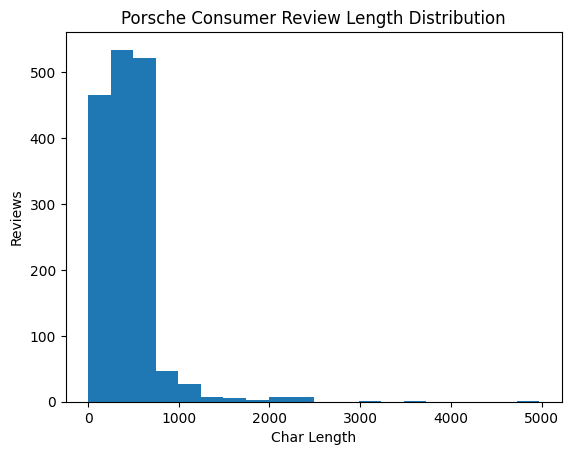

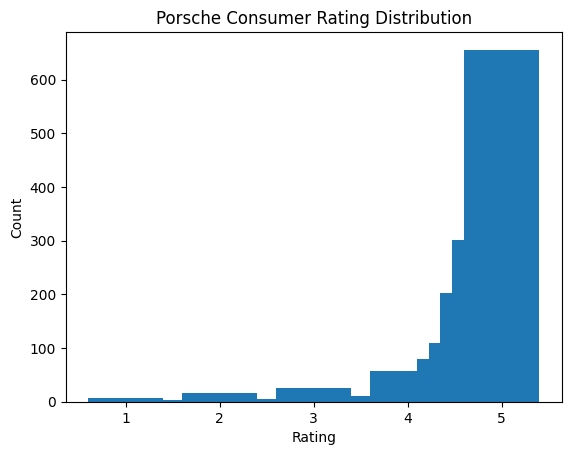

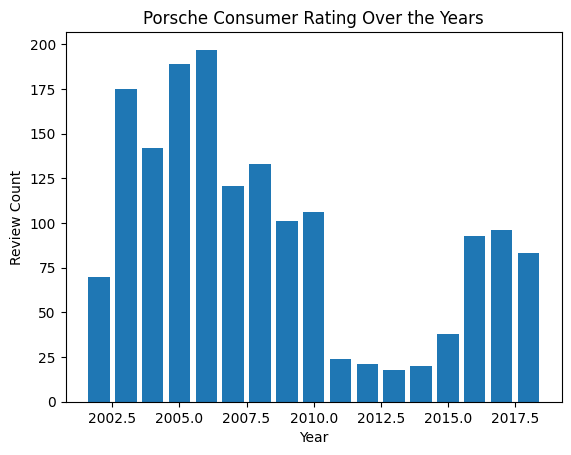

In [6]:
#Load reviews.csv into a pd.DataFrame named car_rev
import pandas as pd
import matplotlib.pyplot as plt

#Read and clean data
car_rev = pd.read_csv('/content/drive/MyDrive/porschereviews.csv', on_bad_lines='skip', engine='python')
car_rev = car_rev.dropna()
car_rev = car_rev.drop_duplicates()
clean_time = car_rev['Review_Date'].str.extract(r'(\d{2}/\d{2}/\d{2} \d{2}:\d{2} [AP]M)')[0] #remove "on"
car_rev['Review_Date_dt'] = pd.to_datetime(clean_time, format='%m/%d/%y %H:%M %p') #add formatting for the date column to extract dates in numeric

#Initial View of data size and columns
print("Rows: " + str(car_rev.shape[0]) + " Columns: " + str(car_rev.shape[1]))
print()
print(car_rev.info())
print()
print(car_rev.head(n=5))

#EDA: Column exploration
vehicle_counts = car_rev['Vehicle_Title'].value_counts(ascending=False, normalize=False)
ratings = car_rev['Rating'].value_counts(ascending=False, normalize=False)
review_len = car_rev['Review'].str.len()
year_count = car_rev['Review_Date_dt'].dt.year.value_counts(ascending=False, normalize=False)

print()
print(vehicle_counts)
print()
print(ratings)
print()
print(review_len)
print()
print(year_count)

#A matplotlib for distribution plotting of review length
plt.hist(review_len, bins=20)
plt.title("Porsche Consumer Review Length Distribution")
plt.xlabel("Char Length")
plt.ylabel("Reviews")
plt.show()

#Ratings
plt.bar(ratings.index, ratings.values)
plt.title("Porsche Consumer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#Years
plt.bar(year_count.index, year_count.values)
plt.title("Porsche Consumer Rating Over the Years")
plt.xlabel("Year")
plt.ylabel("Review Count")
plt.show()


# (C) Motivation and Feasibility – Ex:
- Motivation: EDA shows long-tail and temporal clustering
- Non-triviality: Course techniques alone ignore ordering
- Feasibility: External algorithm learnable and implementable
- Risks: Computational cost, parameter sensitivity
- Additionally perform any additional EDA you need to in order to ensure the method is feasible.



## Motivation and Feasibility

* Motivation: The EDA I conducted in the previous project checkpoint exposed a few inconsistencies within the data. For example, the number of reviews posted between 2010 and 2015 dropped by almost 75%. Furthermore, I am curious to see what the text analysis of customer reviews will reveal that could possibly contradict the numerical rating they gave.
* Non-triviality: Course techniques alone ignore ordering
* Feasibility: The algorithms for the course topics are familiar and have been performed in tandem with clustering techniques before. The external topic algorithm, LDA, is feasible but may not be able to achieve high accuracy in a short time. It needs a fixed number of expected topics which may be difficult to gauge given that the reviews are open ended. Although car models could be used as topic models, the context of reviews across different ones would be lost. Therefore, working with LDA would be a trial and error experiment to achieve the best result.
* Risks: Certain clustering algorithms can be computationally costly, and the embedding and topic modeling algorithms are sensitive to input parameters. Careful random seed selection and documentation of parameters and their scores are necessary for reproduction.

Word map of frequently used words:

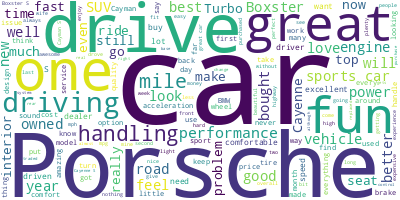

In [9]:
#from Medium: word chart

# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ' '.join(list(car_rev['Review'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

This word map at a glance provides some insight into the overall tone from reviews. This can be compared to the semantics extracted from text mining later on in the study. Apart from the obviously common words, (Porsche, car, drive, one) a few interesting ones are fun, great, performance, handling, comfort, etc. These are all potential topics that could be used for topic modeling, so a map like this could be a good baseline for identifying a set number of topics.

# (D) Methodological Planning – Ex:
- Course algorithms: Apriori, FP-Growth
- External algorithms: PrefixSpan
- Evaluation: Pattern quality and diversity
- Baselines: High-support-only mining
- Additionally perform any initial method runs (e.g. testing out how packages work, etc.) you need to in order to ensure the methods are feasible.

## Methodological Planning
- Course algorithms: All course-related algorithms were covered in a homework or lecture topic: TF-IDF, Word2Vec, Clustering Methods (PCA, DBSCAN), and BERT.
- External algorithms: For the external topic, Latent Dirichlet Allocation (topic modeling) will be the primary focus for external topics.
- Evaluation: Evaluation of the dataset will vary with different models. Ideally, silhouette scores and how rare TF-IDF determines a term is during matrix creation will facilitate text mining. Additionally, topic coherence can be used to measure the relevance of a topic based on the supporting context.
- Baselines: Baselines for text mining will be established using a simpler Bag-Of-Words approach, and TF-IDF will be the baseline for embeddings. For topic modeling, high frequency words will be used as the baseline.

Package installation and confirmation:

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.6 MB/s eta 0:00:00


In [3]:
#used for LDA
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Resources

RESOURCES

On my honor, I declare the following resources:
1. Collaborators:
- Myself, consulted Project Checkpoint 1 code to copy EDA results for continuation

2. Web Sources:
- https://rumn.medium.com/bert-score-explained-8f384d37bb06: BERTscore introduction for embedding evaluations
- https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/: Understanding interpretation of topic coherence
- https://medium.com/@yongjinL/beyond-manual-coding-a-practical-guide-to-using-lda-for-qualitative-data-analysis-e8f6c08ab2ad: Managing LDA and its feasibility
- https://medium.com/data-science/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0: LDA package installation and testing, gave idea for word chart showcasing common words in reviews

3. AI Tools:
- ChatGPT: Asked to help refine research questions
- ChatGPT: Asked for an algorithm used in topic modeling and for an evaluation metric (outside of course)
- ChatGPT: Helped identify baselines for the text mining and LDA algorithms

4. Papers:
- None